# Fase 1: Carga y Caracterización del Dataset

El objetivo de esta sección es realizar una **caracterización técnica** del conjunto de datos. Esto servirá como la "ficha técnica" en el informe final, permitiendo identificar la magnitud y estructura de la información que estamos analizando.

### Objetivos:
- Cargar el dataset de urgencias.
- Identificar el número de registros (filas) y variables (columnas).
- Inspeccionar los nombres y tipos de datos de las variables.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética para los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Cargamos el dataset
path = '../data/urgencias_noprocesados_grupo08.csv'
df = pd.read_csv(path, encoding='latin-1') # Usamos latin-1 por caracteres especiales detectados

# Vista preliminar
print("Primeros registros del dataset:")
display(df.head())

## Caracterización Técnica

En esta sección utilizamos `.info()`, `.shape` y `.columns` para obtener la información estructural requerida para el informe.

In [2]:
print("--- Dimensiones del Dataset (.shape) ---")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

print("\n--- Listado de Columnas (.columns) ---")
print(df.columns.tolist())

print("\n--- Información General y Tipos de Datos (.info()) ---")
df.info()

--- Dimensiones del Dataset (.shape) ---
Filas: 4742
Columnas: 29

--- Listado de Columnas (.columns) ---
['ï»¿EstablecimientoCodigo', 'EstablecimientoGlosa', 'RegionCodigo', 'RegionGlosa', 'ComunaCodigo', 'ComunaGlosa', 'ServicioSaludCodigo', 'ServicioSaludGlosa', 'TipoEstablecimiento', 'DependenciaAdministrativa', 'NivelAtencion', 'TipoUrgencia', 'Latitud', 'Longitud', 'NivelComplejidad', 'Anio', 'SemanaEstadistica', 'OrdenCausa', 'Causa', 'NumTotal', 'NumMenor1Anio', 'Num1a4Anios', 'Num5a14Anios', 'Num15a64Anios', 'Num65oMas', 'FechaAtencionTexto', 'SexoPaciente', 'PrioridadTriage', 'CostoAtencionCLP']

--- Información General y Tipos de Datos (.info()) ---
<class 'pandas.DataFrame'>
RangeIndex: 4742 entries, 0 to 4741
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ï»¿EstablecimientoCodigo   4742 non-null   int64  
 1   EstablecimientoGlosa       4742 non-null   str    
 2   Region

> **Importancia:** Esta identificación es crucial para definir el alcance del análisis. Por ejemplo, saber si tenemos miles o millones de registros influye en la estrategia de limpieza y procesamiento.

---
# Fase 2: Análisis Estadístico Descriptivo

En esta etapa buscamos entender el **comportamiento de los números** y detectar posibles anomalías o tendencias generales en los datos cuantitativos.

In [3]:
# Seleccionamos las columnas numéricas de interés
columnas_numericas = [
    'NumTotal', 'NumMenor1Anio', 'Num1a4Anios', 'Num5a14Anios', 
    'Num15a64Anios', 'Num65oMas', 'CostoAtencionCLP'
]

print("--- Resumen Estadístico Descriptivo ---")
display(df[columnas_numericas].describe())

--- Resumen Estadístico Descriptivo ---


,NumTotal,NumMenor1Anio,Num1a4Anios,Num5a14Anios,Num15a64Anios,Num65oMas,CostoAtencionCLP
count,4742.000000,4742.000000,4742.000000,4742.000000,4742.000000,4742.000000,4.724000e+03
mean,147.892240,17.060312,20.074230,27.634542,59.686630,30.435259,9.915792e+04
std,106.672027,48.604953,42.128959,46.561265,65.554012,58.130329,4.825522e+04
min,17.000000,0.000000,0.000000,0.000000,6.000000,0.000000,1.500000e+04
25%,93.000000,5.000000,8.000000,13.000000,34.000000,10.000000,7.830175e+04
50%,138.000000,9.000000,15.000000,23.000000,53.000000,20.000000,9.794150e+04
75%,188.000000,16.750000,24.000000,36.000000,76.000000,38.000000,1.170225e+05
max,2763.000000,1819.000000,1796.000000,1472.000000,1685.000000,1386.000000,1.548277e+06


### Qué observar y "Insights":

- **Valores Inconsistentes:** ¿Existen costos en $0 o valores negativos en columnas donde no debería haberlos (ej. cantidad de personas)?
- **Promedios vs Medianas:** Si el promedio es muy diferente a la mediana (50%), indica una distribución sesgada.
- **Outliers (Valores Extremos):** Los valores máximos (`max`) muy alejados del percentil 75% pueden indicar casos atípicos que requieran una revisión especial.

**Nota:** Estos hallazgos son fundamentales para la sección de limpieza y tratamiento de datos en el informe final.

---
# Fase 3: Identificación de Datos "Sucios"

Como este es un dataset **no procesado**, es fundamental identificar las fallas de calidad de datos que deberán ser corregidas en etapas posteriores. Esta sección justifica la necesidad de un proceso de limpieza (Data Cleaning).

### 3.1 Valores Nulos y Duplicados

In [4]:
print("--- Conteo de Valores Nulos (NaN) ---")
print(df.isnull().sum())

print("\n--- Conteo de Filas Duplicadas ---")
print(f"Total duplicados: {df.duplicated().sum()}")

--- Conteo de Valores Nulos (NaN) ---
ï»¿EstablecimientoCodigo      0
EstablecimientoGlosa          0
RegionCodigo                  0
RegionGlosa                   0
ComunaCodigo                  0
ComunaGlosa                   0
ServicioSaludCodigo           0
ServicioSaludGlosa            0
TipoEstablecimiento           0
DependenciaAdministrativa    26
NivelAtencion                 0
TipoUrgencia                 14
Latitud                      19
Longitud                     11
NivelComplejidad             24
Anio                          0
SemanaEstadistica             0
OrdenCausa                    0
Causa                         0
NumTotal                      0
NumMenor1Anio                 0
Num1a4Anios                   0
Num5a14Anios                  0
Num15a64Anios                 0
Num65oMas                     0
FechaAtencionTexto           18
SexoPaciente                 18
PrioridadTriage              18
CostoAtencionCLP             18
dtype: int64

--- Conteo de Filas 

### 3.2 Inconsistencias Específicas Detectadas

A continuación, inspeccionamos las variables donde se han identificado problemas de formato u outliers según las observaciones iniciales.

In [5]:
print("--- Inconsistencias en FechaAtencionTexto (Muestra) ---")
print(df['FechaAtencionTexto'].unique()[:15]) # Mostramos los primeros 15 formatos únicos

print("\n--- Outliers en SexoPaciente (Valores únicos) ---")
print(df['SexoPaciente'].unique())

print("\n--- Problemas en PrioridadTriage (Valores únicos) ---")
print(df['PrioridadTriage'].unique())

print("\n--- Columnas con mayor cantidad de vacíos ---")
vacios = df.isnull().sum()
print(vacios[vacios > 0].sort_values(ascending=False))

--- Inconsistencias en FechaAtencionTexto (Muestra) ---
<StringArray>
['02-01-2023',   '02.01.23', '2023/01/02', '09-01-2023', '2023/01/09',
   '09.01.23', '2023/01/16', '16-01-2023',   '16.01.23', '23-01-2023',
   '23.01.23', '2023/01/23', '2023/01/30',   '30.01.23', '30-01-2023']
Length: 15, dtype: str

--- Outliers en SexoPaciente (Valores únicos) ---
<StringArray>
['M', 'F', nan, 'masculino', 'X', 'SinDato', 'femenino']
Length: 7, dtype: str

--- Problemas en PrioridadTriage (Valores únicos) ---
<StringArray>
['C2', 'C4', 'C1', 'C3', 'C5', 'C4 ', 'c1', nan, 'desconocido', ' c2', 'C-3']
Length: 11, dtype: str

--- Columnas con mayor cantidad de vacíos ---
DependenciaAdministrativa    26
NivelComplejidad             24
Latitud                      19
SexoPaciente                 18
FechaAtencionTexto           18
PrioridadTriage              18
CostoAtencionCLP             18
TipoUrgencia                 14
Longitud                     11
dtype: int64


### Resumen de Hallazgos:
- **Formatos de Fecha:** Se observan formatos mixtos con guiones `-` y puntos `.`, lo que impedirá un análisis temporal directo sin conversión.
- **Variables Críticas Vacías:** Columnas como `DependenciaAdministrativa`, `Latitud` y `Longitud` presentan una alta tasa de nulos.
- **Categorías Sucias:** `SexoPaciente` y `PrioridadTriage` contienen valores inconsistentes o fuera de rango (Outliers).

---

# Fase 4: Visualización Inicial

La visualización nos permite identificar patrones de forma intuitiva. En esta etapa, generamos gráficos básicos para entender la distribución de las variables principales.

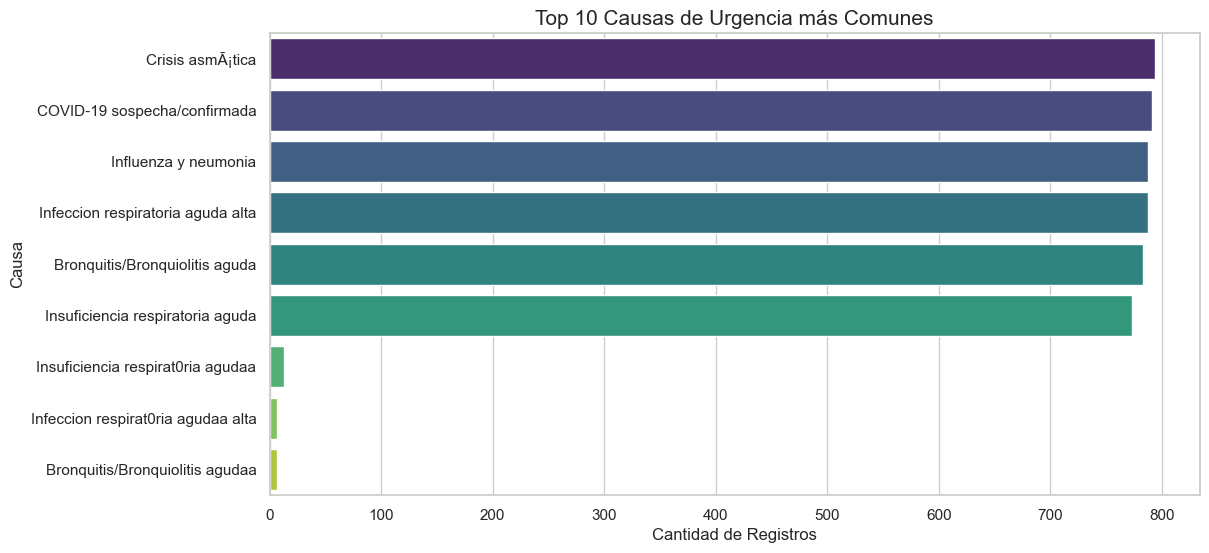

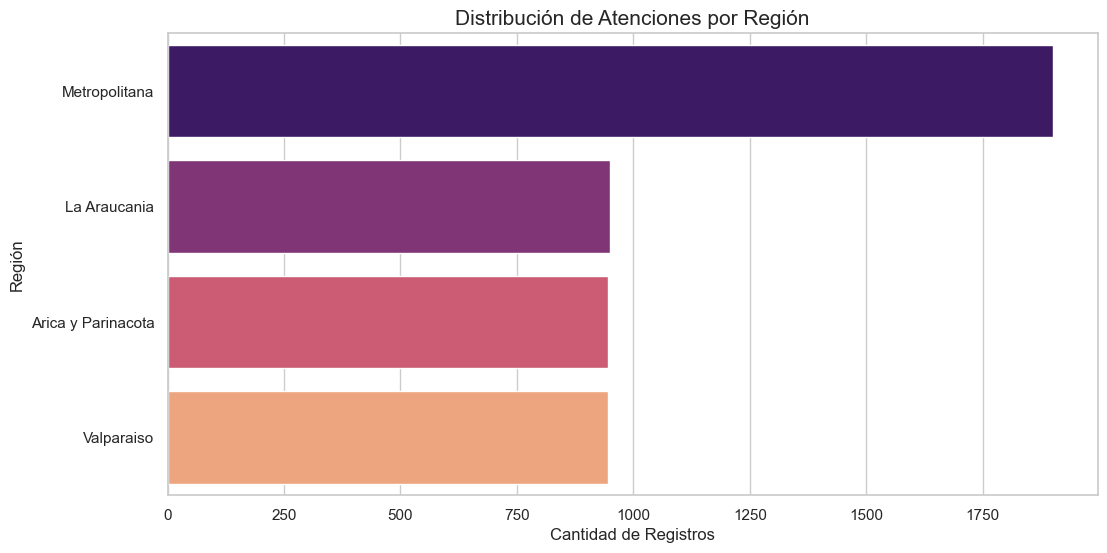

In [6]:
# 1. Gráfico de Barras: Top 10 Causas de Urgencia
plt.figure(figsize=(12, 6))
top_causas = df['Causa'].value_counts().head(10)
sns.barplot(x=top_causas.values, y=top_causas.index, palette='viridis', hue=top_causas.index, legend=False)
plt.title('Top 10 Causas de Urgencia más Comunes', fontsize=15)
plt.xlabel('Cantidad de Registros')
plt.ylabel('Causa')
plt.show()

# 2. Distribución de Atenciones por Región
plt.figure(figsize=(12, 6))
region_dist = df['RegionGlosa'].value_counts()
sns.barplot(x=region_dist.values, y=region_dist.index, palette='magma', hue=region_dist.index, legend=False)
plt.title('Distribución de Atenciones por Región', fontsize=15)
plt.xlabel('Cantidad de Registros')
plt.ylabel('Región')
plt.show()

In [ ]:
print("Análisis exploratorio y visualización inicial finalizados. El dataset está listo para la fase de limpieza.")